In [46]:
import pandas as pd

In [47]:
teams = pd.read_csv("teams.csv")

In [48]:
teams

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,19,26,25.0,179.0,71.1,0,0.0,0.0
2140,ZIM,Zimbabwe,2004,11,14,25.1,177.8,70.5,3,0.0,0.0
2141,ZIM,Zimbabwe,2008,15,16,26.1,171.9,63.7,4,3.0,1.0
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3


In [49]:
teams.select_dtypes(include='number').corr()["medals"]

,medals
year,-0.021603
events,0.771330
athletes,0.840817
age,0.025096
height,0.141055
weight,0.090577
medals,1.000000
prev_medals,0.920048
prev_3_medals,0.918438


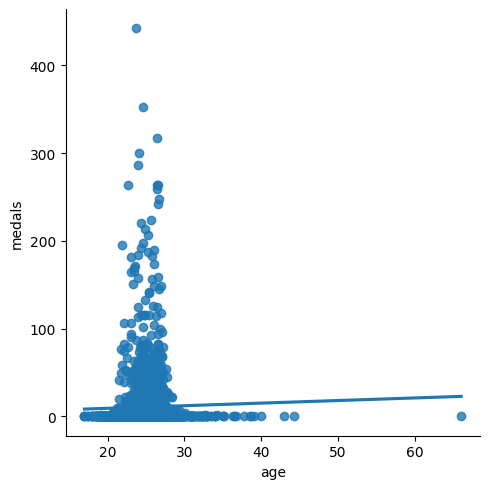

In [50]:
import seaborn as sns
sns.lmplot(x="age", y="medals", data=teams, fit_reg=True, ci=None)

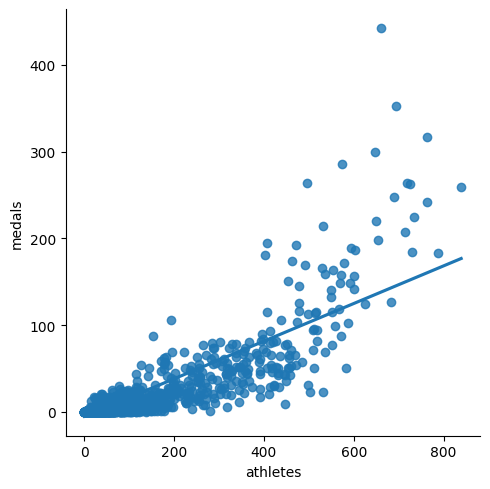

In [51]:
import seaborn as sns
sns.lmplot(x="athletes",y="medals", data=teams, fit_reg=True, ci=None)

<Axes: >

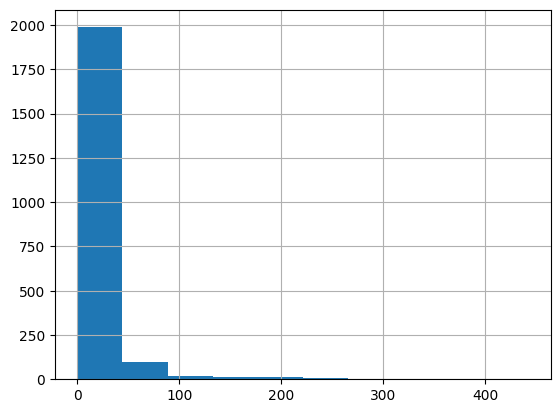

In [52]:
teams["medals"].hist()

In [53]:
teams[teams.isnull().any(axis=1)]

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
19,ALB,Albania,1992,8,9,25.3,163.0,75.2,0,NaN,NaN
26,ALG,Algeria,1964,7,7,26.0,175.0,65.0,0,NaN,NaN
39,AND,Andorra,1976,2,3,28.3,174.7,78.0,0,NaN,NaN
50,ANG,Angola,1980,14,17,17.4,171.7,62.5,0,NaN,NaN
59,ANT,Antigua and Barbuda,1976,11,17,23.2,178.6,71.6,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2092,VIN,Saint Vincent and the Grenadines,1988,6,6,20.5,157.0,57.0,0,NaN,NaN
2103,YAR,North Yemen,1984,3,3,27.7,163.3,57.7,0,NaN,NaN
2105,YEM,Yemen,1992,8,8,19.6,169.0,60.0,0,NaN,NaN
2112,YMD,South Yemen,1988,5,5,23.6,175.0,63.3,0,NaN,NaN


In [54]:
train = teams[teams["year"] < 2012].copy()
test = teams[teams["year"] >= 2012].copy()

In [55]:

test = test.dropna()
print("Shape of test DataFrame after dropping NaNs:")

Shape of test DataFrame after dropping NaNs:


In [56]:
test.shape

(405, 11)

In [57]:

train = train.dropna()
print("Shape of train DataFrame after dropping NaNs:")

Shape of train DataFrame after dropping NaNs:


In [58]:
train.shape

(1609, 11)

In [59]:
train.shape

(1609, 11)

In [60]:
test.shape

(405, 11)

In [61]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [62]:
predictors = ["athletes", "prev_medals"]
target = "medals"

In [63]:
reg.fit(train[predictors],train["medals"])

LinearRegression()

In [64]:
predictions = reg.predict(test[predictors])

In [65]:
predictions = reg.predict(test[predictors])

print(predictions[:5])

[-0.96122125 -1.17633261 -1.42503158 -1.71184673  2.15562926]


In [66]:
test["predictions"] = predictions

In [67]:
test

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals,predictions
6,AFG,Afghanistan,2012,6,6,24.8,171.7,60.8,1,1.0,0.3,-0.961221
7,AFG,Afghanistan,2016,3,3,24.7,173.7,74.0,0,1.0,0.7,-1.176333
24,ALB,Albania,2012,9,10,25.7,176.8,80.2,0,0.0,0.0,-1.425032
25,ALB,Albania,2016,6,6,23.7,176.2,67.2,0,0.0,0.0,-1.711847
37,ALG,Algeria,2012,29,39,24.8,174.3,66.9,1,2.0,2.3,2.155629
...,...,...,...,...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,3,19.3,169.7,65.7,0,0.0,0.0,-1.926958
2131,ZAM,Zambia,2012,7,7,22.6,176.2,74.2,0,0.0,0.0,-1.640143
2132,ZAM,Zambia,2016,7,7,24.1,175.2,67.5,0,0.0,0.0,-1.640143
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3,1.505767


In [68]:
test.loc[test["predictions"] < 0, "predictions"] = 0

In [69]:
test["predictions"] = test["predictions"].round()

In [70]:
test

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals,predictions
6,AFG,Afghanistan,2012,6,6,24.8,171.7,60.8,1,1.0,0.3,0.0
7,AFG,Afghanistan,2016,3,3,24.7,173.7,74.0,0,1.0,0.7,0.0
24,ALB,Albania,2012,9,10,25.7,176.8,80.2,0,0.0,0.0,0.0
25,ALB,Albania,2016,6,6,23.7,176.2,67.2,0,0.0,0.0,0.0
37,ALG,Algeria,2012,29,39,24.8,174.3,66.9,1,2.0,2.3,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,3,19.3,169.7,65.7,0,0.0,0.0,0.0
2131,ZAM,Zambia,2012,7,7,22.6,176.2,74.2,0,0.0,0.0,0.0
2132,ZAM,Zambia,2016,7,7,24.1,175.2,67.5,0,0.0,0.0,0.0
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3,2.0


In [71]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(test["medals"], test["predictions"])

In [72]:
error

3.2987654320987656

In [73]:
teams.describe()["medals"]

,medals
count,2144.000000
mean,10.556437
std,33.028143
min,0.000000
25%,0.000000
50%,0.000000
75%,4.000000
max,442.000000


In [74]:
test[test["team"]== "USA"]

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals,predictions
2053,USA,United States,2012,245,689,26.7,178.3,74.7,248,317.0,274.0,285.0
2054,USA,United States,2016,245,719,26.4,178.0,73.8,264,248.0,276.0,236.0


In [75]:
test[test["team"]== "IND"]

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals,predictions
907,IND,India,2012,55,95,26.0,174.2,72.7,6,3.0,1.7,7.0
908,IND,India,2016,67,130,26.1,170.0,66.3,2,6.0,3.3,12.0


In [76]:
errors = (test["medals"] - test["predictions"]).abs()

In [77]:
errors

,0
6,1.0
7,0.0
24,0.0
25,0.0
37,1.0
...,...
2111,0.0
2131,0.0
2132,0.0
2142,2.0


In [78]:
error_by_team = errors.groupby(test["team"]).mean()

In [79]:
error_by_team

,0
team,
AFG,0.5
ALB,0.0
ALG,1.5
AND,0.0
ANG,0.0
...,...
VIE,1.0
VIN,0.0
YEM,0.0


In [80]:
medals_by_team = test["medals"].groupby(test["team"]).mean()

In [81]:
error_ratio = error_by_team / medals_by_team

In [82]:
error_ratio

,0
team,
AFG,1.0
ALB,NaN
ALG,1.0
AND,NaN
ANG,NaN
...,...
VIE,1.0
VIN,NaN
YEM,NaN


In [83]:
error_ratio[pd.isnull(error_ratio)]

,0
team,
ALB,NaN
AND,NaN
ANG,NaN
ANT,NaN
ARU,NaN
...,...
URU,NaN
VAN,NaN
VIN,NaN


In [84]:
import numpy as np
error_ratio = error_ratio[np.isfinite(error_ratio)]

In [85]:
error_ratio

,0
team,
AFG,1.000000
ALG,1.000000
ARG,0.853659
ARM,0.428571
AUS,0.367347
...,...
UKR,0.951220
USA,0.126953
UZB,0.625000


<Axes: ylabel='Frequency'>

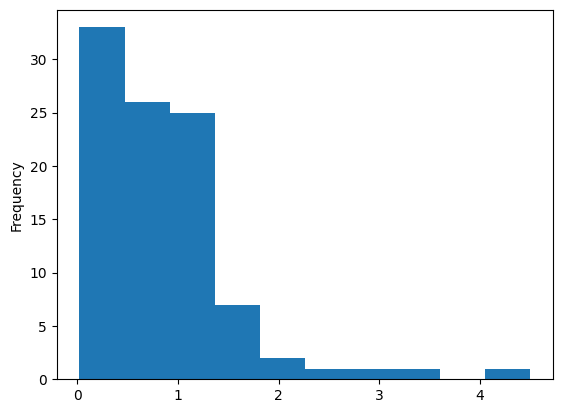

In [86]:
error_ratio.plot.hist()

In [87]:
error_ratio.sort_values()

,0
team,
FRA,0.022472
CAN,0.048387
NZL,0.063492
RUS,0.082353
ITA,0.121429
...,...
MAR,2.000000
EGY,2.400000
HKG,3.000000
